KNN
Activity-9

Given enough samples of handwritten specimen, using a KNN classifier, identify any new letter/ number based on it's appearance similarity with the sample data.

Images: (1797, 64) | classes: [0 1 2 3 4 5 6 7 8 9]


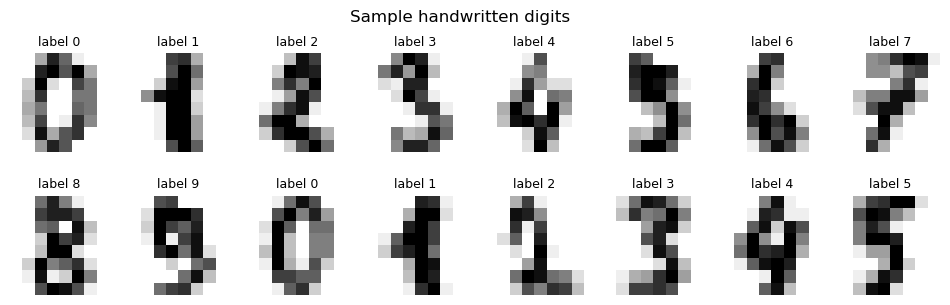

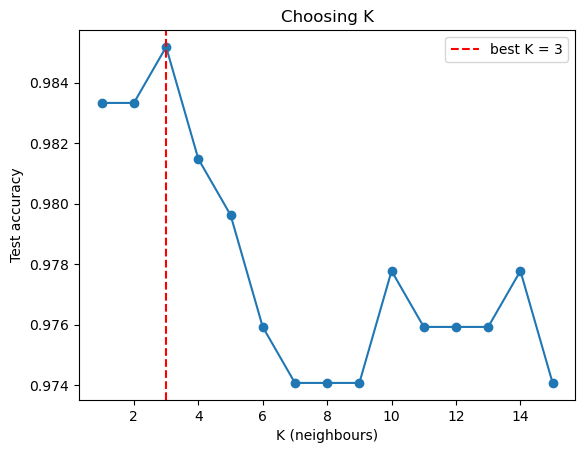

Accuracy per K: [0.9833, 0.9833, 0.9852, 0.9815, 0.9796, 0.9759, 0.9741, 0.9741, 0.9741, 0.9778, 0.9759, 0.9759, 0.9759, 0.9778, 0.9741]
KNN (K=3) accuracy: 0.9852

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.95      1.00      0.97        55
           2       1.00      1.00      1.00        53
           3       0.95      0.98      0.96        55
           4       1.00      0.96      0.98        54
           5       1.00      1.00      1.00        55
           6       1.00      1.00      1.00        54
           7       0.98      1.00      0.99        54
           8       1.00      0.94      0.97        52
           9       0.98      0.96      0.97        54

    accuracy                           0.99       540
   macro avg       0.99      0.99      0.99       540
weighted avg       0.99      0.99      0.99       540



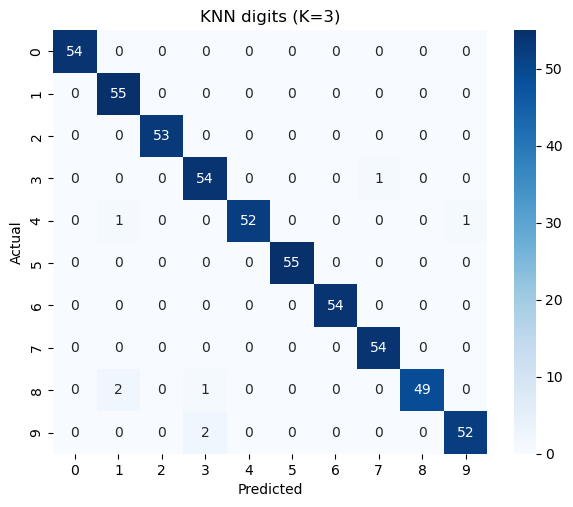

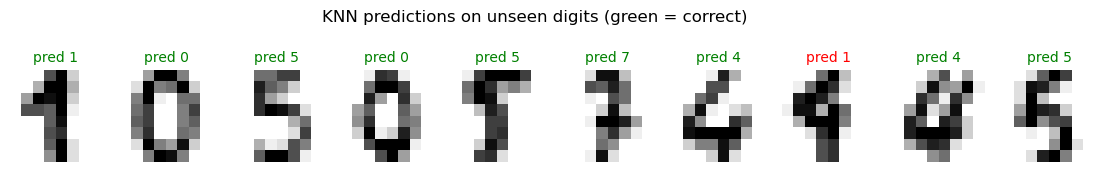

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

digits = load_digits()
X, y = digits.data, digits.target
print("Images:", X.shape, "| classes:", np.unique(y))

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, img, lab in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(img, cmap="gray_r"); ax.set_title(f"label {lab}", fontsize=9); ax.axis("off")
plt.suptitle("Sample handwritten digits"); plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

# Choose K by comparing accuracy for K = 1..15
ks = range(1, 16)
acc = [KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train).score(X_test, y_test) for k in ks]
best_k = ks[int(np.argmax(acc))]

plt.plot(ks, acc, "o-"); plt.axvline(best_k, color="r", ls="--", label=f"best K = {best_k}")
plt.xlabel("K (neighbours)"); plt.ylabel("Test accuracy"); plt.title("Choosing K"); plt.legend(); plt.show()
print("Accuracy per K:", [round(a, 4) for a in acc])

knn = KNeighborsClassifier(n_neighbors=best_k, metric="minkowski", p=2).fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f"KNN (K={best_k}) accuracy: {metrics.accuracy_score(y_test, y_pred):.4f}\n")
print(metrics.classification_report(y_test, y_pred))

plt.figure(figsize=(7, 5.5))
sns.heatmap(metrics.confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"KNN digits (K={best_k})"); plt.show()

# Identify some new digits by appearance similarity to the samples
idx = np.random.default_rng(1).choice(len(X_test), 10, replace=False)
fig, axes = plt.subplots(1, 10, figsize=(14, 2.2))
for ax, i in zip(axes, idx):
    ax.imshow(X_test[i].reshape(8, 8), cmap="gray_r"); ax.axis("off")
    pred = knn.predict(X_test[i:i+1])[0]
    ax.set_title(f"pred {pred}", color="green" if pred == y_test[i] else "red", fontsize=10)
plt.suptitle("KNN predictions on unseen digits (green = correct)"); plt.show()

Exercise 2 – Euclidean distance between a new entry and the existing data

In [2]:
import pandas as pd
import numpy as np

# Given dataset
data = {
    "Brightness": [40, 50, 60, 10, 70, 60, 25],
    "Saturation": [20, 50, 90, 25, 70, 10, 80],
    "Class": ["Red", "Blue", "Blue", "Red", "Blue", "Red", "Blue"]
}

df = pd.DataFrame(data)

print("Given Data:")
print(df)

# New entry
new_brightness = 50
new_saturation = 40

print("\nNew Entry:")
print("Brightness =", new_brightness)
print("Saturation =", new_saturation)

# Calculate Euclidean distance
df["Distance"] = np.sqrt(
    (df["Brightness"] - new_brightness) ** 2 +
    (df["Saturation"] - new_saturation) ** 2
)

print("\nEuclidean Distances:")
print(df)

# Sort according to distance
sorted_df = df.sort_values("Distance")

print("\nSorted by Distance:")
print(sorted_df)

# Nearest 3 neighbors
k = 3
nearest = sorted_df.head(k)

print("\n3 Nearest Neighbors:")
print(nearest)

# Majority class
prediction = nearest["Class"].mode()[0]

print("\nPredicted Class:", prediction)

Given Data:
   Brightness  Saturation Class
0          40          20   Red
1          50          50  Blue
2          60          90  Blue
3          10          25   Red
4          70          70  Blue
5          60          10   Red
6          25          80  Blue

New Entry:
Brightness = 50
Saturation = 40

Euclidean Distances:
   Brightness  Saturation Class   Distance
0          40          20   Red  22.360680
1          50          50  Blue  10.000000
2          60          90  Blue  50.990195
3          10          25   Red  42.720019
4          70          70  Blue  36.055513
5          60          10   Red  31.622777
6          25          80  Blue  47.169906

Sorted by Distance:
   Brightness  Saturation Class   Distance
1          50          50  Blue  10.000000
0          40          20   Red  22.360680
5          60          10   Red  31.622777
4          70          70  Blue  36.055513
3          10          25   Red  42.720019
6          25          80  Blue  47.169906
